# SVC Processing Pipeline — Interactive Demo

This notebook runs the **whole pipeline** on SVC HR-1024i `.sig` scans and draws a
plot at every step. It works out of the box on the bundled demo data, and on **your
own data** by editing a single settings cell.

| Part | What it does |
|---|---|
| 1 — Single spectrum | Load → inspect raw → process → visualize each step |
| 2 — Full folder | Load → filter references & outliers → process → save |
| 3 — Pairs (by position) | Average consecutive scans → plot individuals + means |
| 4 — Groups (by scan number) | Average by the scan number in each filename (real-data way) |

Every code cell is explained in the text or comments just above it. Run the cells
top to bottom with **Shift + Enter**.

## Instrument overview

The SVC HR-1024i is a field spectroradiometer that records reflectance across the
visible, near-infrared, and shortwave-infrared regions using **three detector
arrays**:

| Detector array | Region | Approximate range |
|---|---:|---:|
| Silicon | VNIR | 340–1012 nm |
| InGaAs | SWIR-1 | 972–1910 nm |
| Extended InGaAs | SWIR-2 | 1894–2517 nm |

Because the arrays overlap, each raw `.sig` file contains three sequential sensor
segments with small discontinuities that must be trimmed, matched, smoothed, and
resampled into one continuous curve from 400–2500 nm.

## 1. Setup

Import the helpers, define your **settings** (the "config"), then let the pipeline
prepare the files.

In [1]:
# Make the project importable whether this notebook is launched from the repo root
# or from the notebooks/ folder, then import the demo helpers.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[0]          # launched from notebooks/ -> step up
for import_path in (PROJECT_ROOT, PROJECT_ROOT / "notebooks"):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from pipeline_demo.svc import (
    build_config,            # turn a few settings into a pipeline config
    verify_demo_data,        # (demo only) checksum the bundled .sig files
    Spectrum,                # one scan
    SpectraCollection,       # a folder of scans
    save_spectra_csv,        # write processed spectra to CSV
    average_pairs,           # Part 3: average scans by position
    plot_paired_averages,
    average_groups,          # Part 4: average scans by scan number
    plot_groups,
)
print("Helpers imported. Project root:", PROJECT_ROOT)

Helpers imported. Project root: /Users/nr466/Python Projects/svcProcessingPipeline


### Your settings — edit these

This cell is your **config**. To process your own scans, change `DATA_FOLDER` to the
folder that holds your `.sig` files (and `OUTPUT_FOLDER` to wherever you want the
results saved). Leave `INSTRUMENT = "auto"` to detect the instrument from the file
headers, or set it to `"bronze"` or `"silver"`.

`END_LINE` is the wavelength where **Stage 1** trims each scan. Leave it `None` to use
the instrument's calibrated default (`2520.4` nm for bronze, `2517.9` nm for silver).
Only set it if the default doesn't match where your scans end — if it's off, the files
aren't trimmed and you'll see "sensor sweeps" warnings later. Give it a wavelength
string like `"2517.9"` that appears near the end of your data.

In [2]:
# Folder of RAW .sig files. Defaults to the bundled demo data.
#   -> Change DATA_FOLDER to your own folder to process your own scans.
DEMO_SPECTRA = PROJECT_ROOT / "notebooks/pipeline_demo/demo_data/spectra"
DATA_FOLDER  = DEMO_SPECTRA

# Where processed files and CSVs are written (created automatically).
OUTPUT_FOLDER = PROJECT_ROOT / "pipeline_outputs/notebook_run"

# "auto" detects the instrument from the file headers; or use "bronze" / "silver".
INSTRUMENT = "auto"

# Stage 1 truncation wavelength. None -> use the instrument's calibrated default
# (bronze 2520.4 nm, silver 2517.9 nm). Override with a string, e.g. "2517.9",
# if the default doesn't match where your scans end.
END_LINE = None

### Build the config

`build_config()` bundles those settings, detects which instrument took the scans, and
fills in the parity-verified Stage 2 parameters. Printing `config` shows what it
resolved.

In [3]:
config = build_config(
    data_folder=DATA_FOLDER,
    output_folder=OUTPUT_FOLDER,
    instrument=INSTRUMENT,
    end_line=END_LINE,
)
config            # show a friendly summary: instrument, end line, paths, processing params

PipelineConfig
  data folder   : /Users/nr466/Python Projects/svcProcessingPipeline/notebooks/pipeline_demo/demo_data/spectra
  output folder : /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run
  instrument    : bronze
  band range    : 400-2500 nm
  resample FWHM : 10.0 nm

### (Optional) verify the bundled demo data

The demo `.sig` files are external and checksum-verified against a manifest. This
check only applies to the bundled demo — it is skipped automatically when you point
`DATA_FOLDER` at your own scans.

In [4]:
# Demo-only integrity check; harmless to leave in when using your own data.
if DATA_FOLDER == DEMO_SPECTRA:
    verify_demo_data(DATA_FOLDER, PROJECT_ROOT / "notebooks/pipeline_demo/demo_data_manifest.json")
    print("Demo data verified.")
else:
    print("Using your own data — skipping the demo checksum check.")

Demo data verified.


### Prepare the files — Stage 1

`config.prepare()` truncates each raw `.sig` file at the end wavelength shown in the
config summary above (`END_LINE`, or the instrument default) and writes the result into
the processed folder. This is **Stage 1** of the pipeline; every step after this reads
the truncated files.

If `prepare()` warns that the end line wasn't found in your files, set `END_LINE` in the
settings cell and re-run from there.

In [5]:
config.prepare()

Stage 1 complete - truncated 15 file(s)
  raw       : /Users/nr466/Python Projects/svcProcessingPipeline/notebooks/pipeline_demo/demo_data/spectra
  processed : /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run/processed_sig


PipelineConfig
  data folder   : /Users/nr466/Python Projects/svcProcessingPipeline/notebooks/pipeline_demo/demo_data/spectra
  output folder : /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run
  instrument    : bronze
  band range    : 400-2500 nm
  resample FWHM : 10.0 nm

---
## Part 1 — a single spectrum, step by step

Loading one scan makes each stage easy to see.

The summary below doubles as an **instrument check**:
- `sensor count = 3` confirms a three-array instrument (Si + InGaAs + extended InGaAs)
- the `splice wavelengths` near ~984 nm and ~1896 nm are the array boundaries

If those look unexpected, double-check `DATA_FOLDER` before processing everything.

In [ ]:
# Load the first processed scan from the config's folder, and print a summary.
spectra_path = "notebooks/pipeline_demo/demo_data/spectra/bottom.HR.072825..0001.sig" # First scan is a reference scan so we are loading the second scan for demonstration purposes
spectrum = Spectrum.from_config(config, PROJECT_ROOT / spectra_path)
print(spectrum)

Spectrum
  name              : bottom.HR.072825..0001
  bands             : 1024  (339.1 – 2520.4 nm)
  sensor count      : 3
  splice wavelengths: ['984.2 nm', '1896.1 nm']
  reflectance range : 0.0282 – 0.4264
  processed         : False



### Raw

Plotted in file order, the wavelength axis **folds back twice** — once near 1000 nm
and once near 1830 nm — because each new detector array starts at a lower wavelength
than the previous one ended. That fold-back is the artifact the pipeline corrects.

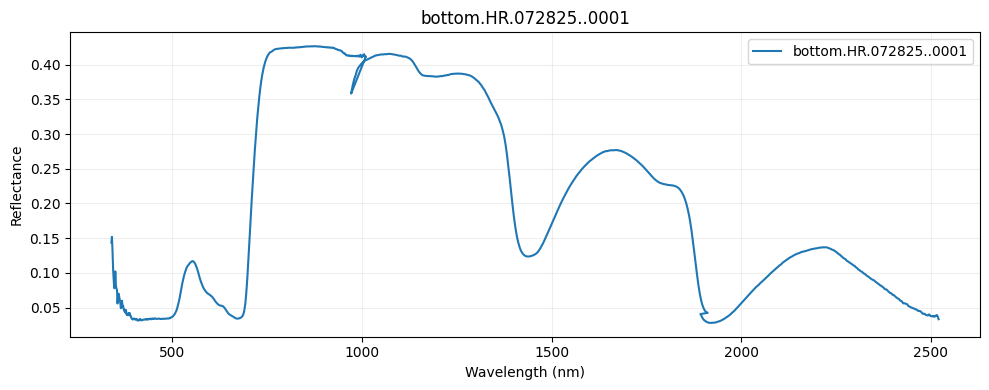

<Axes: title={'center': 'bottom.HR.072825..0001'}, xlabel='Wavelength (nm)', ylabel='Reflectance'>

In [28]:
spectrum.plot()        # raw reflectance, in file order

### Process — Stage 2

`process()` runs Stage 2: trim the sensor overlaps, align the detectors with a
multiplicative splice correction, Gaussian-smooth, and resample onto the clean
400–2500 nm grid (using the parameters from your config).

In [29]:
spectrum.process()
print(spectrum)        # now "processed : True", output on the 400-2500 nm grid

Spectrum
  name              : bottom.HR.072825..0001
  bands             : 1024  (339.1 – 2520.4 nm)
  sensor count      : 3
  splice wavelengths: ['984.2 nm', '1896.1 nm']
  reflectance range : 0.0282 – 0.4264
  processed         : True



### Processing steps

Three panels show the spectrum at each stage. Red dashed lines mark the splice
wavelengths.

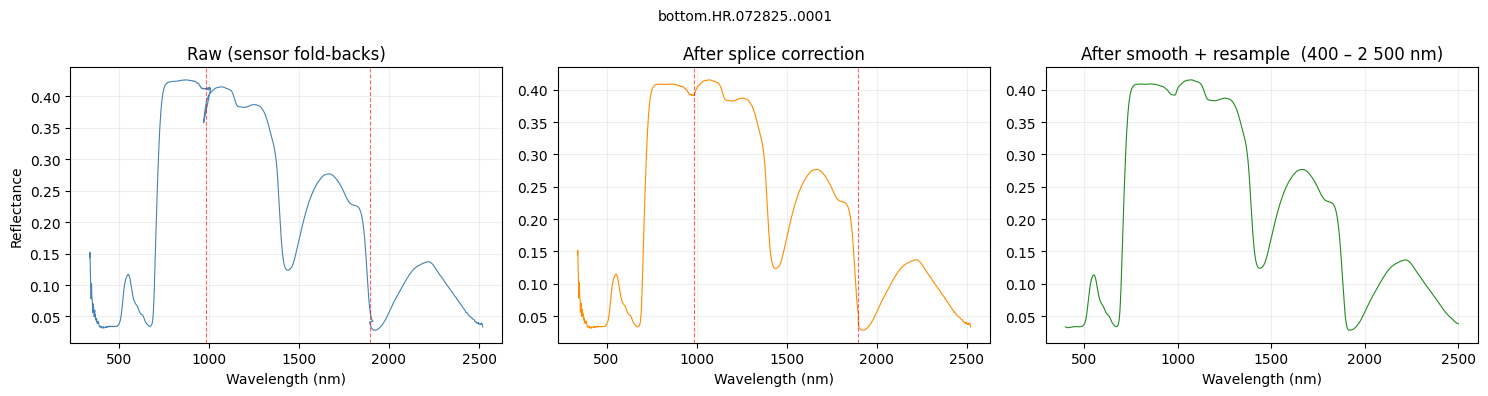

In [30]:
spectrum.plot_processing_steps()

---
## Part 2 — a whole folder

The same pipeline now runs on every scan. Two filters first remove scans that should
not be analysed:
- **Reference panels** — the white Spectralon target (reflectance ≈ 1.0 everywhere).
- **Outliers** — scans whose mean reflectance is far from the group (e.g. obstructed
  view, instrument not settled).

In [31]:
# Load every processed scan; the collection honours the config's Stage 2 settings.
collection = SpectraCollection.from_config(config)
print(collection)

SpectraCollection
  name      : processed_sig
  spectra   : 15
  processed : 0 / 15



### Raw — all scans

The raw plot shows the sensor fold-backs for every scan. Reference panels appear as
nearly flat lines up near reflectance 1.0.

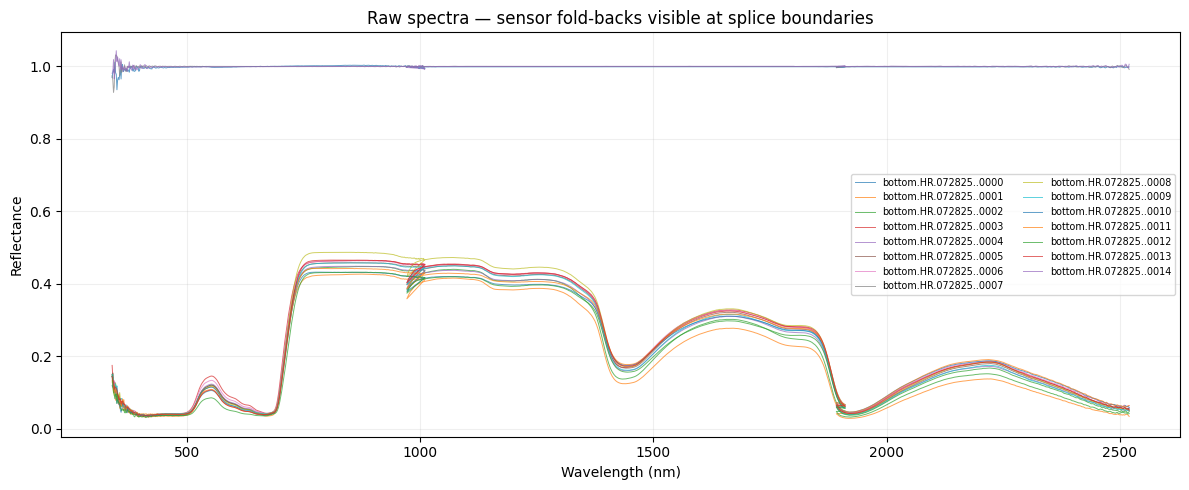

In [32]:
collection.plot_raw()

### Filter

Remove the reference panels first, then the outliers (so the panels don't skew the
outlier statistics). Each call prints how many scans it removed.

In [33]:
collection.filter_reference_scans()    # drop white-reference panels
collection.filter_outliers()           # drop scans far from the group mean

filter_reference_scans: removed 3, 12 remaining.
filter_outliers:        removed 0, 12 remaining.


SpectraCollection
  name      : processed_sig
  spectra   : 12
  processed : 0 / 12

### Process every scan

In [34]:
collection.process()                   # Stage 2 on every remaining scan
print(collection)

SpectraCollection
  name      : processed_sig
  spectra   : 12
  processed : 12 / 12



### Check one scan

A three-panel before/after on one scan confirms the pipeline ran correctly.

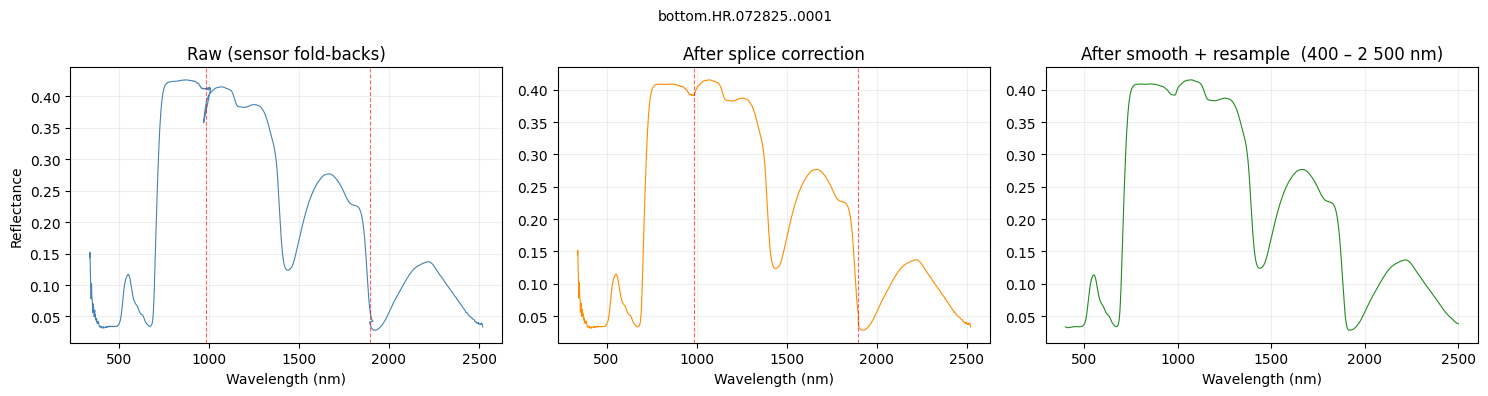

In [35]:
collection.plot_processing_steps(spectrum_index=0)

### All cleaned spectra

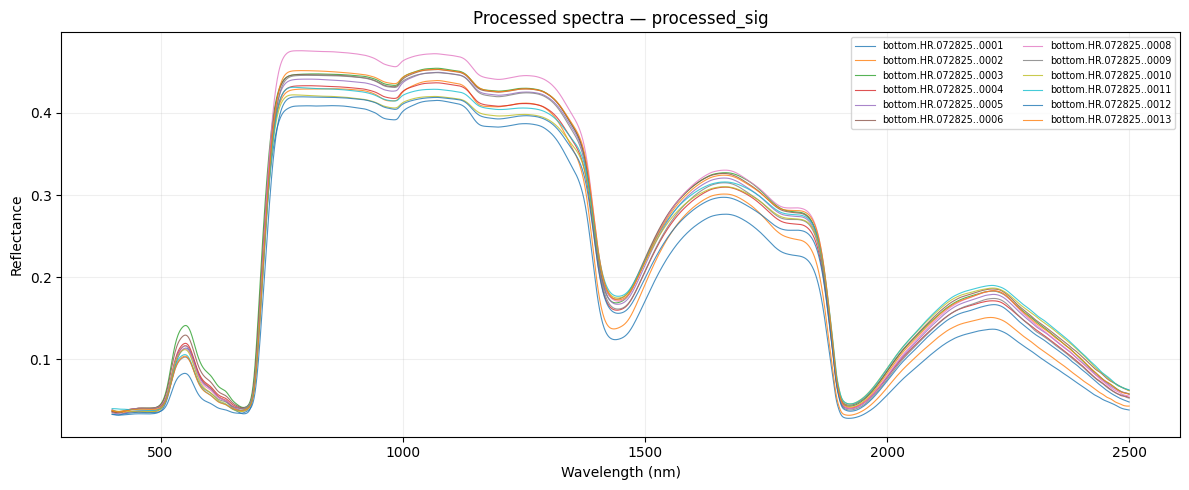

In [36]:
collection.plot()                      # every cleaned scan overlaid

### Save

Write the cleaned spectra to CSV: one row per scan, wavelength columns 400–2500 nm.
We keep the path in `spectra_csv` for the grouping steps below.

In [37]:
spectra_csv = save_spectra_csv(collection, config.output_folder / "spectra.csv")
print("Saved:", spectra_csv)

Saved: /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run/spectra.csv


---
## Part 3 — averaging repeat scans (by position)

Field work often takes several scans per sample. The simplest way to average them is
by **position** in the list — e.g. scans 0 and 1 are one sample, 2 and 3 the next.
Quick and intuitive; see Part 4 for the robust, real-data approach.

### Which position is which file?

In [38]:
# Position (index) -> filename, so you can choose groups deliberately.
for i, s in enumerate(collection.spectra):
    print(f"[{i}] {s.name}")

[0] bottom.HR.072825..0001
[1] bottom.HR.072825..0002
[2] bottom.HR.072825..0003
[3] bottom.HR.072825..0004
[4] bottom.HR.072825..0005
[5] bottom.HR.072825..0006
[6] bottom.HR.072825..0008
[7] bottom.HR.072825..0009
[8] bottom.HR.072825..0010
[9] bottom.HR.072825..0011
[10] bottom.HR.072825..0012
[11] bottom.HR.072825..0013


### Define pairs and average

Each tuple is a set of **0-based positions**. The tuples can be consecutive,
non-consecutive, or written out of order; edit them to match your own measurement
design.

In [ ]:
# Groups use 0-based positions in collection.spectra.
# They do not need to be consecutive or written in sorted order.
groups = [
    (0, 1),    # first two spectra
    (2, 3),    # next two spectra
    (5, 4),    # unordered pair: still averages positions 4 and 5
    (6, 8),    # non-consecutive pair
    (7, 9),
    (10, 11),
]

print("Groups to average:", groups)
pairs = average_pairs(collection, groups=groups)
print(pairs)

Individual scans are drawn faded behind their bold group mean — one colour per
pair — so you can see both within-pair agreement and between-pair variation.

In [ ]:
plot_paired_averages(collection, pairs, groups=groups)

### Save the pairs

In [20]:
# One row per pair, wavelength columns 400-2500 nm.
paired_csv = config.output_folder / "spectra_paired.csv"
pairs.to_csv(paired_csv)
print("Saved:", paired_csv)

Saved: /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run/spectra_paired.csv


---
## Part 4 — grouping by scan number (real data)

Real datasets don't group by position — they group by the **scan number** baked into
each filename (the trailing number, e.g. `...0003` → scan 3). Grouping by number is
robust to filtering and reordering, and it's exactly how the production pipeline and
the `naming_ids/` lookup tables work.

### Define groups by scan number

Below we pair up the scan numbers that survived filtering. For a real project you'd
instead keep the groupings in a small CSV (columns `scans`, `name`) so a
non-programmer can edit them in a spreadsheet, then load them with one line (shown
commented). See `naming_ids/README.md`.

In [21]:
# Scan number = the trailing number in each filename.
scan_numbers = sorted(int(s.name.split(".")[-1]) for s in collection.spectra)
number_groups = [tuple(scan_numbers[i:i + 2]) for i in range(0, len(scan_numbers), 2)]
print("Grouping by scan number:", number_groups)

# For your own data, load the groupings from a naming_ids CSV instead:
#   from pipeline.processor import GroupSpec
#   number_groups = GroupSpec.from_csv("naming_ids/your_table.csv")

Grouping by scan number: [(1, 2), (3, 4), (5, 6), (8, 9), (10, 11), (12, 13)]


`average_groups()` reads the saved CSV and averages by scan number; `plot_groups()`
draws the individual scans faded under their group means.

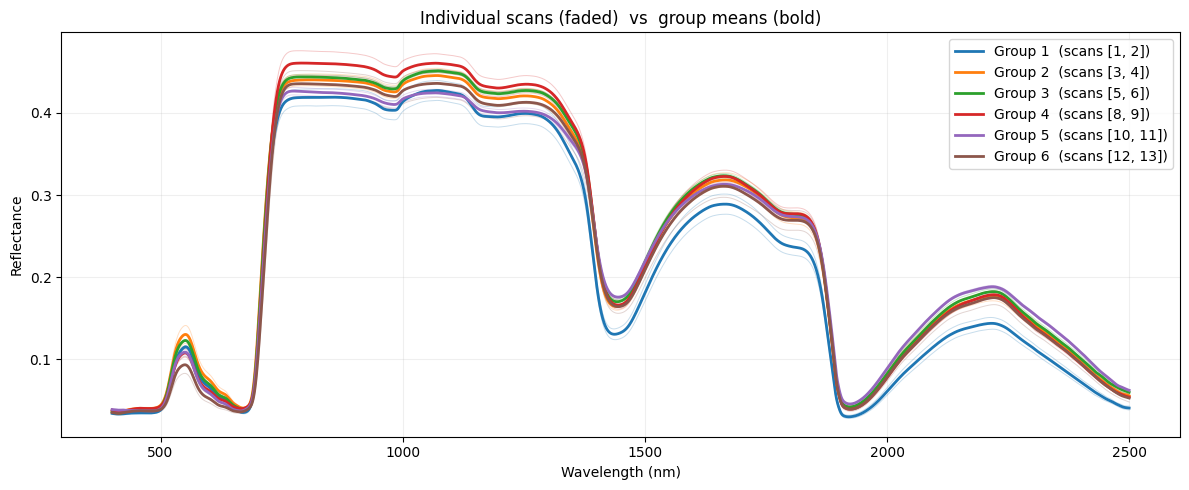

In [22]:
grouped = average_groups(spectra_csv, number_groups)
plot_groups(spectra_csv, number_groups, grouped)

### Save the groups

In [23]:
grouped_csv = config.output_folder / "spectra_grouped.csv"
grouped.to_csv(grouped_csv, index=False)
print("Saved:", grouped_csv)

Saved: /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run/spectra_grouped.csv


---
## (Optional) Save your settings as a config file

`config.to_json()` writes a `config/config.json`-compatible file. You can hand the
same file to the command-line pipeline for batch processing:
`svc-pipeline path/to/my_config.json`.

In [24]:
config_path = config.to_json(config.output_folder / "my_config.json")
print("Wrote:", config_path)

Wrote: /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/notebook_run/my_config.json
